## Enhanced MLP
- torchify what we have implemented
- Our code is based on the following pytorch design: 

### [Linear](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html#torch.nn.Linear)
- We omit device and dtype  

### [BatchNorm1d](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.batchnorm.BatchNorm1d.html)
#### Params
- we omit the folloing params and set it with default 
- affine: true
    - use $\gamma$ and $\beta$
- track_running_state: true
    - in stage computation for runnin_mean and running_var
- device: CPU
- dtype: float32
#### Implementation
- self.out: we implement this for visualizing-statistic simplicity. Pytorch does not have this
- with torch.no_grad(): (context manager)
    - tell pytorch omits the following code block from building computation graph for later backward propagation.

### Others
```python
for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 #5/3
```
The [gain](https://docs.pytorch.org/docs/stable/nn.init.html#torch.nn.init.calculate_gain) (layer.weight *= 5/3) is necessary, becuase tanh tends to squash (narrow) the distribution of pure output(z). And layer by layer it will cause vanish problem. So that's why we expand the outut first by multiplying the weight with `5/3`. The value `1.0` is for demonstration purpose, we can see that compare to `5/3`, the stds are smaller and saturations are lower for all tanhs in different layers.
Notice that, the gain is too large, causing gradient explosion, too smal causing gradient vanish.

## Ref
- [torch.nn](https://docs.pytorch.org/docs/stable/nn.html)

In [360]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [361]:
words = open('./assets/names.txt', 'r').read().splitlines()

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [362]:
## All global variables
block_size = 3 # context length: how many characters do we take to predict the next one?
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility
vocab_size = len(itos)

In [363]:
# build the dataset
def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## Neural Network Structure

In [364]:
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        # https://docs.PyTorch.org/docs/stable/nn.init.html#torch.nn.init.kaiming_normal_
        '''
        start with noraml distribution and prcocessed by kaiming factor (fan_in**0.5)
        '''
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in**0.5
        self.bias = torch.randn(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        params = [self.weight]
        if self.bias is not None:
            params += [self.bias]
        return params

# BatchNorm1d
## 2 main implementations
"""
1. BatchNorm functionality
2. Exponential smoothing (momentum update)
"""
## Side Notes
"""
train_mode
    - True
        - use batch mean and variance for forward propagation
        - do momentum update for updating runnimg_mean/var
    - False
        - use running_mean/var for forward propagation
"""
class BatchNorm1d:
    def __init__(self, num_features, eps=1e-05, momentum = 0.1):
        self.eps = eps
        # alpha in exponential smoothing
        self.momentum = momentum
        self.training = True
        
        # learnable params from batch norm which are for scaling and shifting the distribution
        ## gain
        self.gamma = torch.ones(num_features)
        ## bias
        self.beta = torch.zeros(num_features)

        
        # buffers for momentum update (defualt is normal distribution N(0, 1^2))
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    # https://arxiv.org/pdf/1502.03167 (P.3)
    def __call__(self, x):
        # Default: batch mean and variacne for forward pass
        xmean = x.mean(0, keepdim = True)
        xvar = x.var(0, keepdim = True)

        if not self.training:
            xmean = self.running_mean 
            xvar = self.running_var
        # In pytorch they are called buffers
        if self.training:
            # We won't run backward propagation on self.running_mean and running_var
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        normed_x = (x - xmean) / torch.sqrt(xvar + self.eps)
        # sefl.out is deviated from pytoerch implementation, here is for data analysis
        self.out = self.gamma * normed_x + self.beta

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh():
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    # there are no learnable params from tanh
    def parameters(self):
        return []

C = torch.randn((vocab_size, n_embd), generator = g)

# Tanh Analysis
# layers = [
#   Linear(n_embd * block_size, n_hidden, bias = False), Tanh(),
#   Linear(           n_hidden, n_hidden, bias = False), Tanh(),
#   Linear(           n_hidden, n_hidden, bias = False), Tanh(),
#   Linear(           n_hidden, n_hidden, bias = False), Tanh(),
#   Linear(           n_hidden, n_hidden, bias = False), Tanh(),
#   Linear(           n_hidden, vocab_size, bias = False),
# ]

# Linear Analysis
# layers = [
#     Linear(n_embd * block_size, n_hidden, bias = False), #Tanh(),
#     Linear(           n_hidden, n_hidden, bias = False), #Tanh(),
#     Linear(           n_hidden, n_hidden, bias = False), #Tanh(),
#     Linear(           n_hidden, n_hidden, bias = False), #Tanh(),
#     Linear(           n_hidden, n_hidden, bias = False), #Tanh(),
#     Linear(           n_hidden, vocab_size),
# ]


# Full Structure (with BatchNorm1d layers)
layers = [
    Linear(block_size * n_embd, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, bias = False), BatchNorm1d(vocab_size),    
]


with torch.no_grad():
    # Make it less confident
    """
    The last layer is softmax probs distribution.
    If the distribution is peaky (some values are really large), then the the layer is overly confident.
    Keep it flatter avoiding early softmax saturation
    """
    # For Tanh and Linear analysis
    # layers[-1].weight *= 0.1
    # For Batchnoraml1d analysis
    layers[-1].gamma *= 0.1
    

    # Apply gain on other linear layers
    for l in layers[:-1]:
        if isinstance(l, Linear):
            l.weight *= 5/3
        
params = [C] + [p for layer in layers for p in layer.parameters()]
print("Total number of params: ", sum([p.nelement() for p in params]))
for p in params:
    p.requires_grad = True

Total number of params:  47024


## Training Process

In [365]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
# This list is only for analyzing distribution of ratio of update_val / current_val
ud = []

for i in range(max_steps):
    # construct minibatch 
    bi = torch.randint(0, Xtr.shape[0], (batch_size,), generator = g)
    Xb, Yb = Xtr[bi], Ytr[bi]

    # forward propagation
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for l in layers:
        x = l(x)
    loss = F.cross_entropy(x, Yb)

    # backward propagation
    for l in layers: 
        l.out.retain_grad() # AFTER_DEBUG: would take out retain_graph https://docs.pytorch.org/tutorials/beginner/understanding_leaf_vs_nonleaf_tutorial.html

    for p in params:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in params:
        p.data += -lr * p.grad

    # Track Stats
    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d} {loss.item():.4f}")
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in params])
    
    if i == 1000:
        break
    # break


      0/ 200000 3.2870



## Tanh Analysis
We analyze the result through, since we only care about the kaiming normalizatoin for now (initialization) 

```python
layers = [
  Linear(n_embd * block_size, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, vocab_size, bias = False),
]

# with just 1 iteration
break
```
### Key notes
- The optimal situation is that activation and gradietn distribution of each layer should be similar
- With tanh the gain 5/3 is the optimal. 0.5 and 3 are used to demonstrate that if the gain is too low or too high, you will have huge difference bettwen each layer.

### Activation distribution
The backward propagation implemention of tanh is 
```python
def _backward():
    # out.grad = dL/d(out), accumulated from all downstream nodes
    self.grad += (1 - t**2) * out.grad
```

**mean** </br>
close to 0 is better, since we want smaller logits at the end. Smaller logits means we won't have extreme large loss which will waste inital iterations to sqush down the loss. Close to 0 wont wasting inital iterations so we can have lower loss (learning patterns) at the end in a sense better training result.

**std** </br>
Too large (Saturation)
The tanh values will mostly distribute at saturation points either -1 or 1, the local gradient will become 0 (1 - t**2) which is gradient vanishing. This means the change of input at this neuron won't have effect on output. The neruon becomes dead neuron.

Too small (deep neural network)
The tanh values will most distribute at centner which is 0, then the local gradient will become `1 * out.grad`. Now there are 2 effects of this, Fristly, the tanh layer lost the non-linearity traits. Secodnly, Even though the Tanh local gradient is at its maximum ($\approx 1.0$), if the weights themselves are also small, the chain rule will multiply many small numbers together across layers, causing the gradient to vanish before it reaches the early layers.

**Saturation** </br>
It is all about `(1 - t**2)`
If most tanh values are at satuation points (tanh(x) is either -1 or 1), then the local gradient will become 0 (1 - t**2).
You get dead neuron (gradient vanishing).


#### Observation
```python
 for l in layers[:-1]:
        if isinstance(l, Linear):
            # l.weight *= 1  # value `1` to demonstrate that the squashing trait of tanh function
            l.weight *= 5/3  
```
- with `self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in**0.5`, we try to conserve the std of tanh to be 1
- tanh layer is squashing distribution narrower, so at the end std << 1
- With 5/3, the first layer has more saturations, so we actaully exapnd the distribution a bit so later tanh squashing can still maintain stabilized std.


layer   2 (   Tanh): mean -0.00, std 0.63, saturated: 2.75%
layer   5 (   Tanh): mean +0.01, std 0.64, saturated: 2.12%
layer   8 (   Tanh): mean -0.00, std 0.65, saturated: 2.22%
layer  11 (   Tanh): mean +0.00, std 0.65, saturated: 2.09%
layer  14 (   Tanh): mean +0.00, std 0.65, saturated: 2.06%


Text(0.5, 1.0, 'activation distribution')

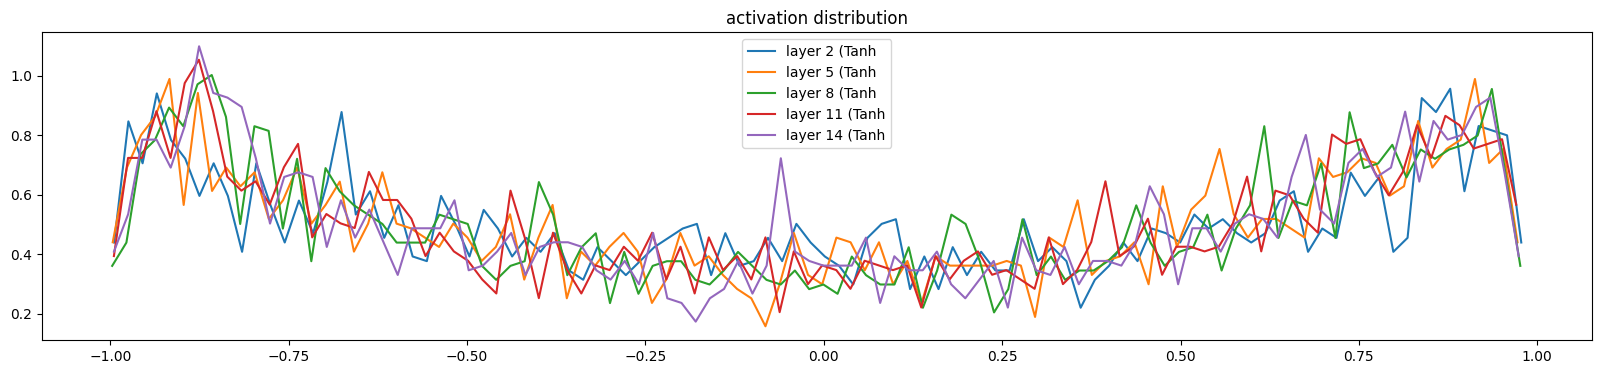

In [353]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %3d (%7s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    # detacht the t from the computaion graph (autograd tracking). PyTorch would complain if you later do backward.
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

### Gradient distribution
- Goal: all layers have roughly same gradient distribution. (`l.weight *= 5/3`)

If we set the wright again as 0.5, we can see that most gradients at first layer are zero, layers close to end tend to have various value. 
If we scale weights by 0.5 in each layer, forward activations shrink and
backward gradients shrink multiplicatively across layers.
```python

layers = [
  Linear(n_embd * block_size, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, vocab_size, bias = False),
]

for l in layers[:-1]:
    if isinstance(l, Linear):
        l.weight *= 0.5

# with just 1 iteration
break

```
- Early layers → tiny gradients (vanishing gradient)
- Later layers → still get signal
- So training mostly adjusts later layers


layer 2 (      Tanh): mean -0.000000, std 3.775106e-03
layer 5 (      Tanh): mean -0.000000, std 3.256986e-03
layer 8 (      Tanh): mean -0.000000, std 2.727380e-03
layer 11 (      Tanh): mean +0.000000, std 2.678559e-03
layer 14 (      Tanh): mean -0.000000, std 2.464119e-03


Text(0.5, 1.0, 'gradient distribution')

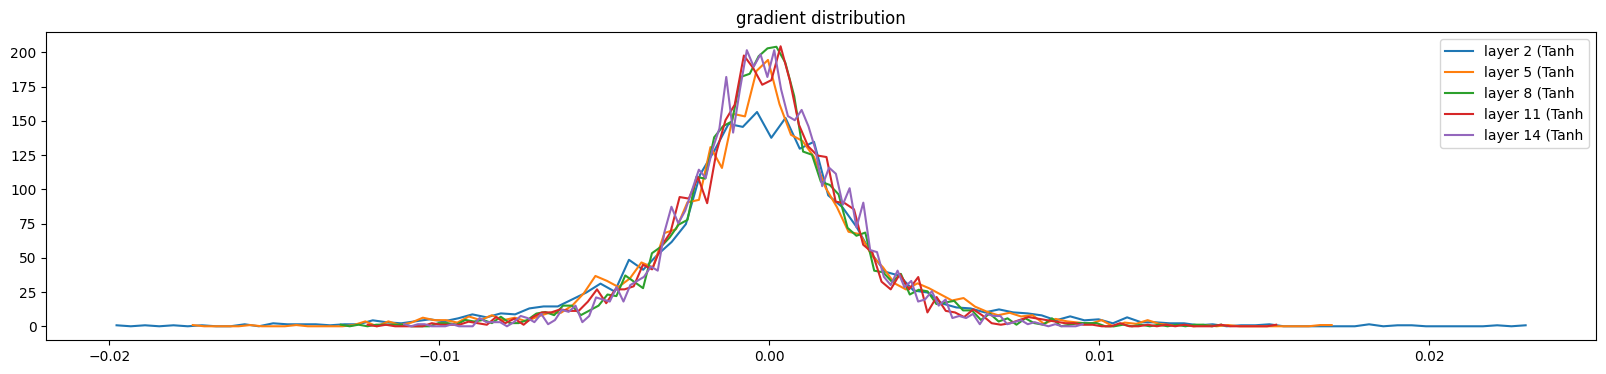

In [354]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

----
## Linear Analysis
Goal: We want to have stabilized activation and gradient distribution. Which means each layers should have roughly similar distributions. 
But we can see that, both activation and gradient distributon of each layer are very different.
- So both 5/3 (too big) and 0.5 (too small) are incoreect gain, for full linear layer 1 is better

Karpathy also demonstrate the case that if the tanh layer is removed.
https://youtu.be/P6sfmUTpUmc?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&t=5640

```python
layers = [
    Linear(n_embd * block_size, n_hidden), #Tanh(),
    Linear(           n_hidden, n_hidden), #Tanh(),
    Linear(           n_hidden, n_hidden), #Tanh(),
    Linear(           n_hidden, n_hidden), #Tanh(),
    Linear(           n_hidden, n_hidden), #Tanh(),
    Linear(           n_hidden, vocab_size),
]
for l in layers[:-1]:
    if isinstance(l, Linear):
        l.weight *= 5/3

# with just 1 iteration
break


```

- 5/3 should be too high,

layer   0 ( Linear): mean -0.22, std 1.71, saturated: 55.03%
layer   3 ( Linear): mean -0.01, std 1.11, saturated: 38.28%
layer   6 ( Linear): mean +0.01, std 1.14, saturated: 41.12%
layer   9 ( Linear): mean -0.00, std 1.17, saturated: 43.28%
layer  12 ( Linear): mean -0.00, std 1.19, saturated: 43.91%
layer  15 ( Linear): mean +0.00, std 1.40, saturated: 46.88%


Text(0.5, 1.0, 'activation distribution')

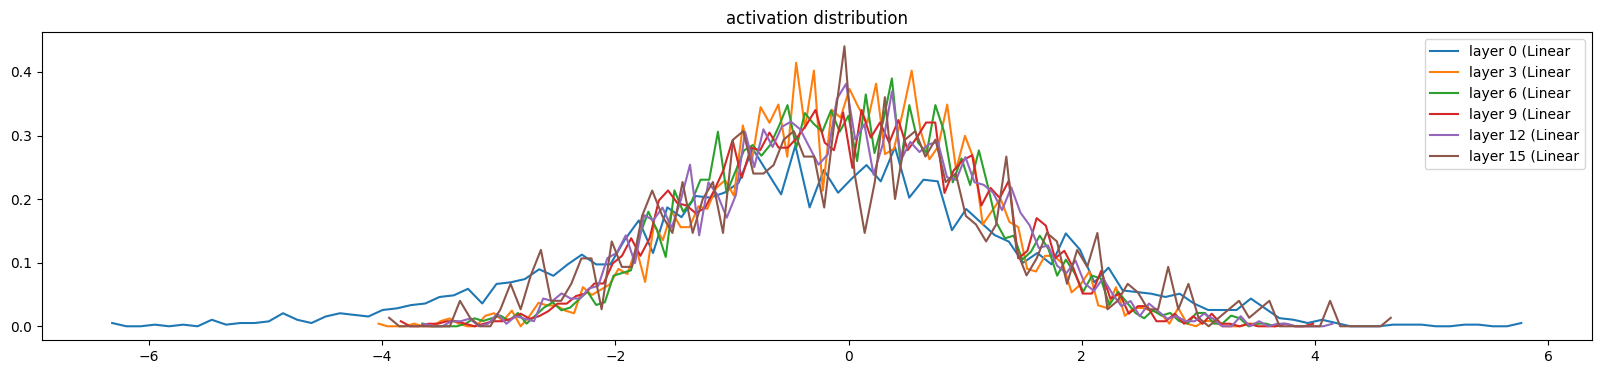

In [355]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Linear):
    t = layer.out
    print('layer %3d (%7s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    # detacht the t from the computaion graph (autograd tracking). PyTorch would complain if you later do backward.
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 0 (    Linear): mean +0.000000, std 1.850978e-03
layer 3 (    Linear): mean +0.000000, std 2.163000e-03
layer 6 (    Linear): mean +0.000000, std 1.859505e-03
layer 9 (    Linear): mean +0.000000, std 1.570626e-03
layer 12 (    Linear): mean -0.000000, std 1.490651e-03
layer 15 (    Linear): mean +0.000000, std 2.910492e-03


Text(0.5, 1.0, 'gradient distribution')

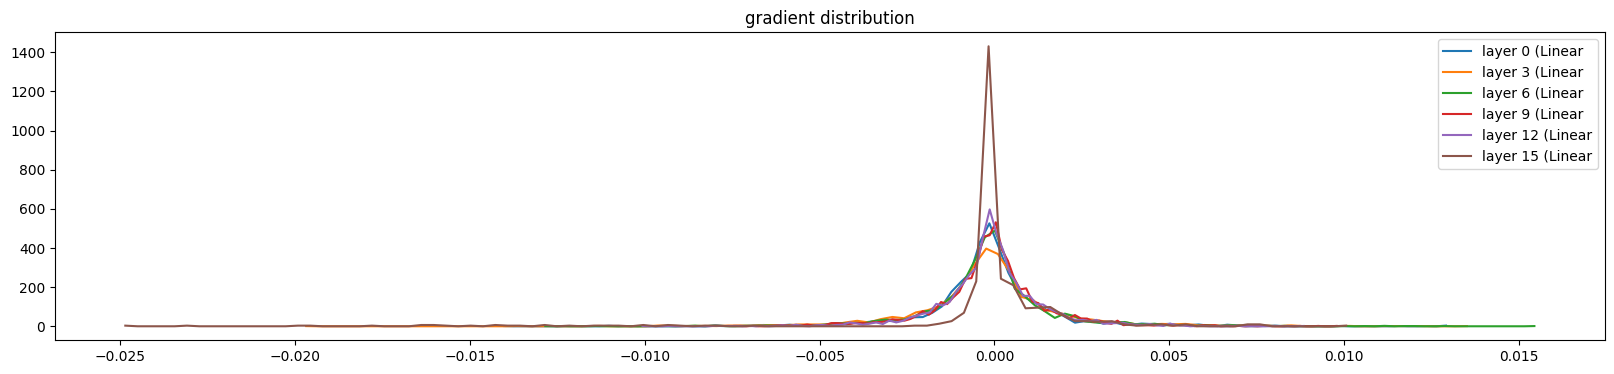

In [356]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Linear):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

---
### Sub Summary
- Before normal layers or adam optimization, training model is hard to balance. As we can see with only Kaiming initialization based on different stricutre you have you need to carefuly select gain value.
- tanh add non-linearity.
    - The model can represnet high degree polynomail funciton. 
- Stack of linear layers us just a huge linear layer.
    - Evevn the forward propagation is a huge stack of linear layer, In backward propagation, optimization in each layer is different. 
---

## Params Distributoin
- We only analyze the weights not bias, gains ...etc.

### Goal
We want to have stabilized activation and gradient distribution. Which means each layers should have roughly similar distributions. 
### Setting

```python

# Tanh Analysis
layers = [
  Linear(n_embd * block_size, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, vocab_size, bias = False),
]

weight *= 5/3

# 1 iteration
break
```


### Weight Gradient Distribution
- $\frac{\text{grad}}{\text{data}}$ ratio: It should be small (but not too small) so that gradient descent will work smoothly, If it is too large, then loss won't converge.
- With 1 iteration
    - The grad/data ratio of laster layer is larger then other layers.
        - This happens because gradients at the last layer are larger, since it is directly connected to the loss.
        - Earlier layers' gradients are reduced through the chain rule.
        - As a result, the last layer updates faster than the rest.
        - This imbalance means the model primarily adjusts the softmax classifier rather than learning deeper feature representations.
- Wiht 1000 iteration
    - The model fix the problem itself, we can see that the weight distributoin of last layer start to centeralize a bit. 

weight   (27, 10) | mean +0.000000 | std 1.019880e-02 | grad:data ratio 1.018841e-02
weight  (30, 100) | mean +0.000092 | std 8.238408e-03 | grad:data ratio 2.635832e-02
weight (100, 100) | mean +0.000031 | std 7.318091e-03 | grad:data ratio 4.377132e-02
weight (100, 100) | mean -0.000019 | std 6.662016e-03 | grad:data ratio 3.949891e-02
weight (100, 100) | mean -0.000019 | std 5.821509e-03 | grad:data ratio 3.468157e-02
weight (100, 100) | mean +0.000053 | std 5.445288e-03 | grad:data ratio 3.243362e-02
weight  (100, 27) | mean -0.000165 | std 1.046843e-02 | grad:data ratio 6.281252e-02


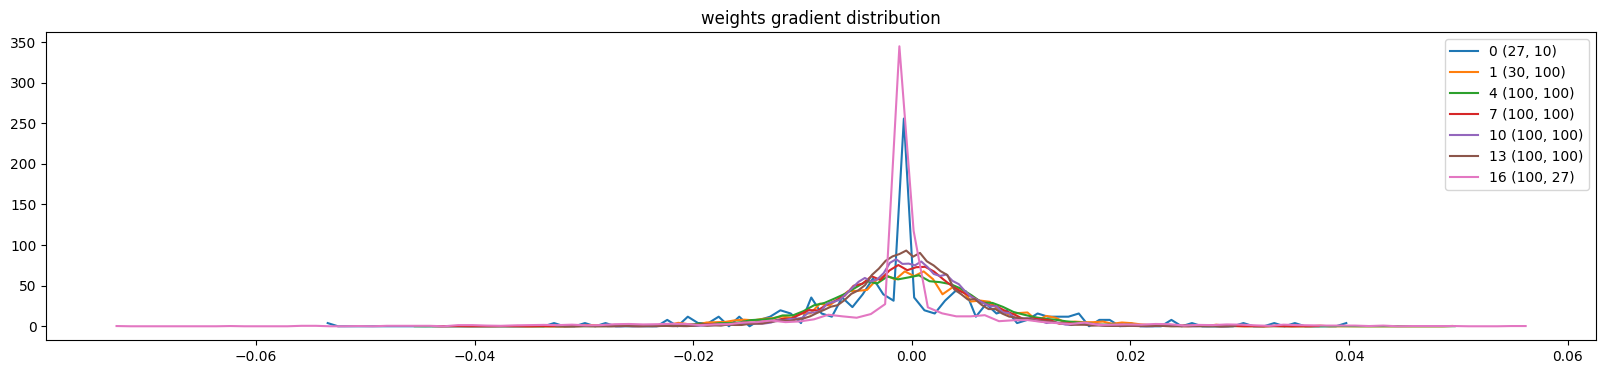

In [372]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(params):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

---

## Update_val / Current_val Analysis
- The ratio e-3 is the standard in this case. The ratio should be around e-3
    - `>> e-3`: learning rate is too large
    - `<< e-3`: learnign rate is too small
- The last layer is larger, because at the begninning, we decrease its confidence intentionally. `layers[-1].weight *= 0.1`
- learning rate (set it to 0.001)
    - The distributions will way below threashold (mode learning is too slow)

### Setting 

```python
# Tanh Analysis
layers = [
  Linear(n_embd * block_size, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, n_hidden, bias = False), Tanh(),
  Linear(           n_hidden, vocab_size, bias = False),
]

weight *= 5/3

# 1000 iteration
if i == 1000:
    break
```

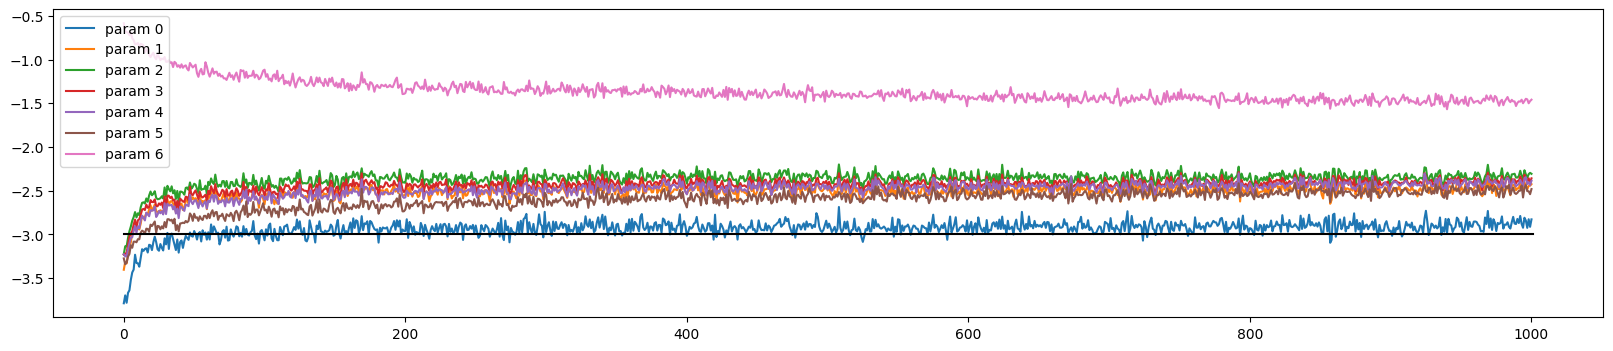

In [315]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(params):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

## Other observations
- We can remove `fan_in**0.5` and see that activation distribuion of all layers are overly saturated.


----

## Linear + BatchNorm


### Setting

```python
layers = [
    Linear(block_size * n_embd, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, bias = False), BatchNorm1d(vocab_size),    
]

# Kaiming Initialziation
- Fully implemented

# 1000 iteration
if i == 1000:
    break
```

### [Observations](https://youtu.be/P6sfmUTpUmc?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&t=6674)
- We can see that distributions of different elements all are similar accross all layers. And initial distribution (first layer) do not have serious saturation problem.
- We can change `l.weight *= 5/3` to `l.weight *= 5`, and all analysis seems to be fine except `Update_val / Current_val Analysis`. The learning rate of distribution seems to drop. So even with batchnorm, we still can't change gain freely.
- We can remove Kaiming to see that although learning rate of `Update_val / Current_val Analysis` distribution drop a bit, but other looks fine. So we can adjust the learngin rate to 1.0 to compensate.



layer   2 (   Tanh): mean -0.00, std 0.63, saturated: 2.62%
layer   5 (   Tanh): mean +0.00, std 0.64, saturated: 2.47%
layer   8 (   Tanh): mean -0.00, std 0.64, saturated: 2.16%
layer  11 (   Tanh): mean +0.00, std 0.65, saturated: 1.81%
layer  14 (   Tanh): mean -0.00, std 0.65, saturated: 1.78%


Text(0.5, 1.0, 'activation distribution')

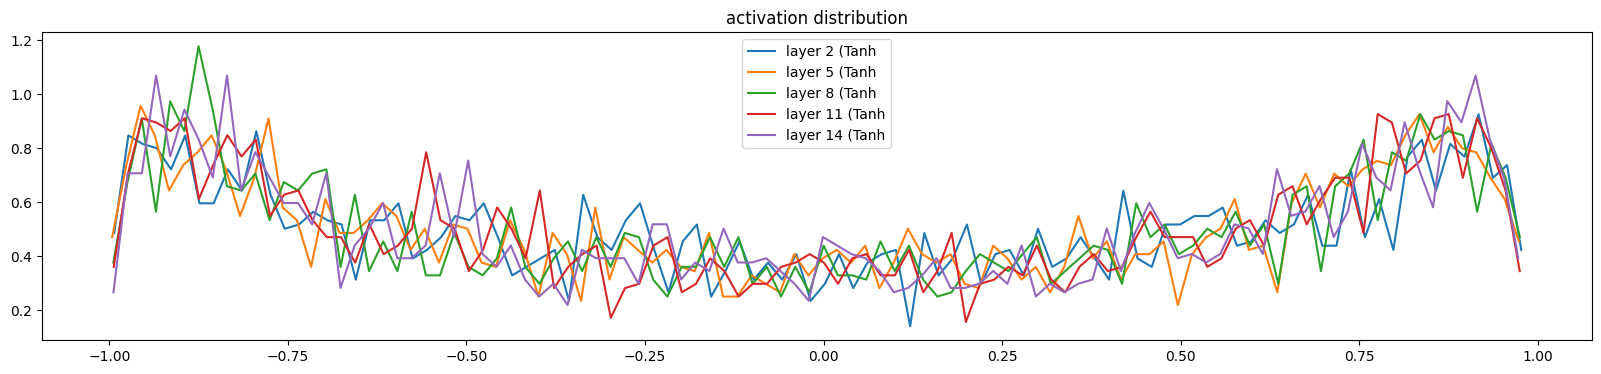

In [366]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %3d (%7s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    # detacht the t from the computaion graph (autograd tracking). PyTorch would complain if you later do backward.
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 3.682945e-03
layer 5 (      Tanh): mean +0.000000, std 3.262603e-03
layer 8 (      Tanh): mean +0.000000, std 2.973725e-03
layer 11 (      Tanh): mean +0.000000, std 2.741104e-03
layer 14 (      Tanh): mean +0.000000, std 2.584291e-03


Text(0.5, 1.0, 'gradient distribution')

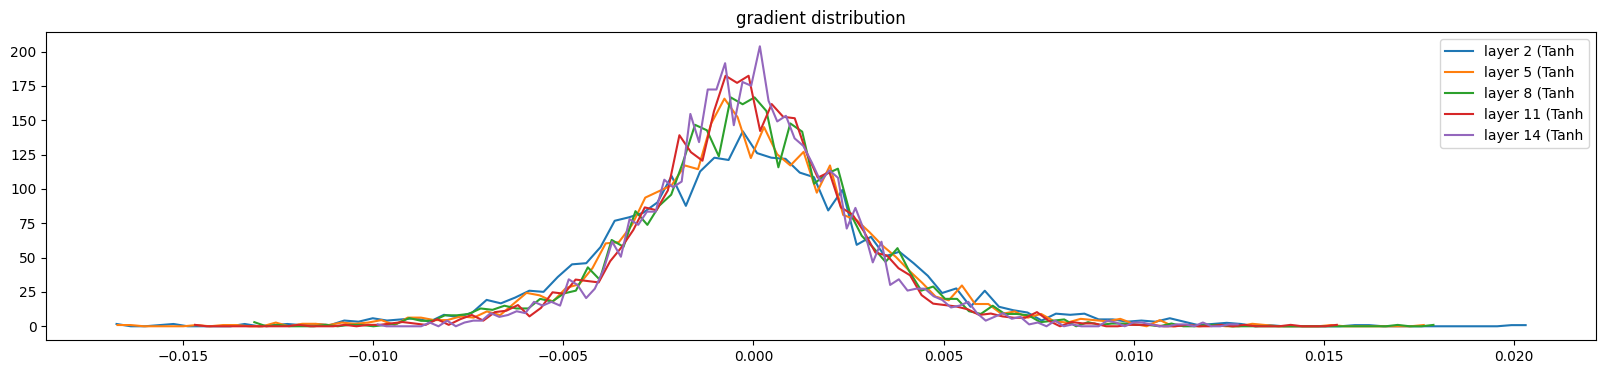

In [369]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 1.019880e-02 | grad:data ratio 1.018841e-02
weight  (30, 100) | mean +0.000092 | std 8.238408e-03 | grad:data ratio 2.635832e-02
weight (100, 100) | mean +0.000031 | std 7.318091e-03 | grad:data ratio 4.377132e-02
weight (100, 100) | mean -0.000019 | std 6.662016e-03 | grad:data ratio 3.949891e-02
weight (100, 100) | mean -0.000019 | std 5.821509e-03 | grad:data ratio 3.468157e-02
weight (100, 100) | mean +0.000053 | std 5.445288e-03 | grad:data ratio 3.243362e-02
weight  (100, 27) | mean -0.000165 | std 1.046843e-02 | grad:data ratio 6.281252e-02


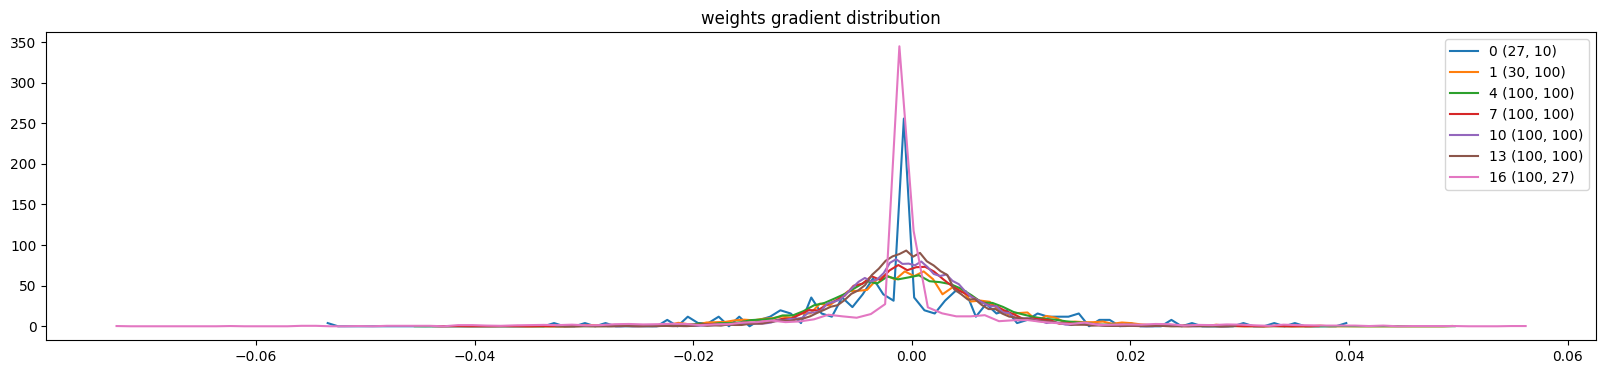

In [370]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(params):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

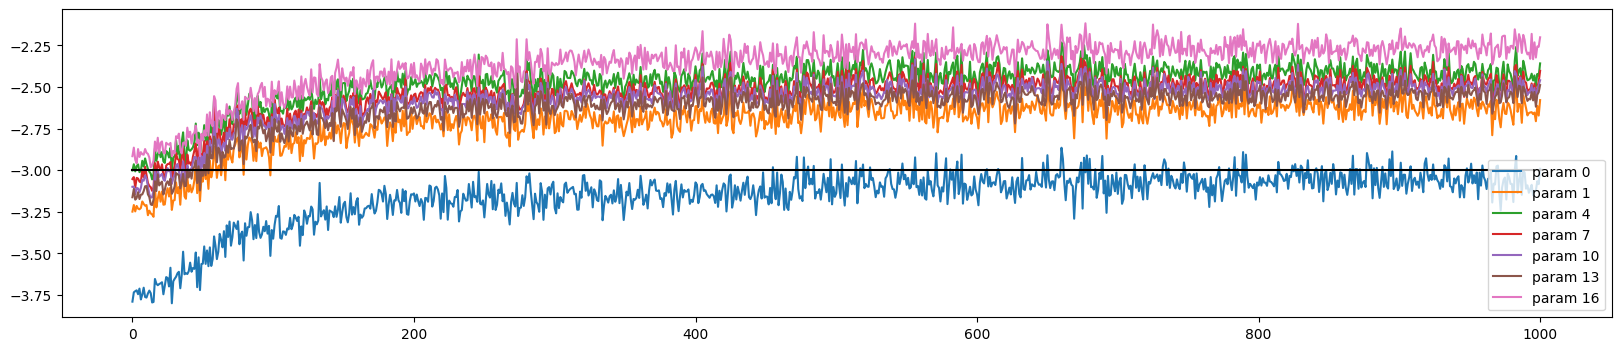

In [371]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(params):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

## Summary 
- For now, the performance bottleneck should be contexnt lenghh (3).